In [159]:
# Load the global life expectancy dataset by country. Source reference: https://worldpopulationreview.com/country-rankings/life-expectancy-by-country

import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
life_expect_db = pd.read_csv("Dataset_Repository/life-expectancy-data-by-country_2026.csv", sep=",")

# Display the dataset for initial inspection and validation
life_expect_db

,flagCode,country,LifeExpectancyViaUN_2024,LifeExpectancyFemalesUN_2024,LifeExpectancyMalesUN_2024
0,MC,Monaco,86.50,88.63,84.56
1,SM,San Marino,85.82,87.22,84.32
2,HK,Hong Kong,85.63,88.26,82.97
3,JP,Japan,84.85,87.88,81.83
4,KR,South Korea,84.43,87.28,81.32
...,...,...,...,...,...
227,LS,Lesotho,57.80,60.44,55.03
228,SS,South Sudan,57.74,60.75,54.76
229,CF,Central African Republic,57.67,59.56,55.51
230,TD,Chad,55.24,57.19,53.36


In [160]:
# Inspect column names in the dataset to identify inconsistencies or formatting issues
life_expect_db.columns

Index(['flagCode', 'country', 'LifeExpectancyViaUN_2024',
       'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024'],
      dtype='object')

In [161]:
# Standardize column names for clarity and consistency; this step improves readability and makes the dataset easier to work with in downstream analysis

life_expect_db = life_expect_db.rename(columns={
    "LifeExpectancyViaUN_2024": "UN_Life_Expectancy",
    "LifeExpectancyFemalesUN_2024": "Female_Life_Expectancy",
    "LifeExpectancyMalesUN_2024": "Male_Life_Expectancy",
    "country": "Country",
    "flagCode": "Flag_Code"
})

# Verify updated column structure
life_expect_db.columns

Index(['Flag_Code', 'Country', 'UN_Life_Expectancy', 'Female_Life_Expectancy',
       'Male_Life_Expectancy'],
      dtype='object')

In [162]:
# Load country-to-continent mapping dataset (used for later joins in analysis)
continents = pd.read_csv("Dataset_Repository/list-of-countries-by-continent-2026.csv", sep=",")

# Preview dataset structure to verify successful load and inspect schema
continents

,flagCode,country,continent,unMember
0,BR,Brazil,South America,True
1,CO,Colombia,South America,True
2,AR,Argentina,South America,True
3,PE,Peru,South America,True
4,VE,Venezuela,South America,True
...,...,...,...,...
230,CV,Cape Verde,Africa,True
231,YT,Mayotte,Africa,False
232,ST,Sao Tome and Principe,Africa,True
233,SC,Seychelles,Africa,True


In [163]:
# Rename dataframe columns to improve readability and consistency for downstream analysis
continents = continents.rename(columns={
    "flagCode": "Flag_Code",
    "country": "Country",
    "continent": "Continent",
    "unMember": "UN_Member"    
})

# Display updated column names to verify successful renaming
continents.columns

Index(['Flag_Code', 'Country', 'Continent', 'UN_Member'], dtype='object')

In [164]:
# The dataset includes ambiguous values such as "Asia, Europe" for Russia. For consistency in downstream analysis, this entry is mapped as "Asia".

continents["Continent"] = continents["Continent"].replace("Asia, Europe", "Asia")
continents

,Flag_Code,Country,Continent,UN_Member
0,BR,Brazil,South America,True
1,CO,Colombia,South America,True
2,AR,Argentina,South America,True
3,PE,Peru,South America,True
4,VE,Venezuela,South America,True
...,...,...,...,...
230,CV,Cape Verde,Africa,True
231,YT,Mayotte,Africa,False
232,ST,Sao Tome and Principe,Africa,True
233,SC,Seychelles,Africa,True


In [165]:
# Remove the 'Flag_Code' column from the continents dataset as it is not required for the analysis and may introduce unnecessary duplication while merging.

continents.drop(columns=["Flag_Code"], inplace=True)
continents

,Country,Continent,UN_Member
0,Brazil,South America,True
1,Colombia,South America,True
2,Argentina,South America,True
3,Peru,South America,True
4,Venezuela,South America,True
...,...,...,...
230,Cape Verde,Africa,True
231,Mayotte,Africa,False
232,Sao Tome and Principe,Africa,True
233,Seychelles,Africa,True


In [166]:
# Merge life expectancy dataset with continent mapping to enrich country-level data using a left join to preserve all records from the life expectancy dataset.

life_expect_db_w_continents = pd.merge(
    life_expect_db,
    continents,
    how="left",                             # Keep all countries in the main dataset
    on="Country",                           # Join key shared by both datasets
    sort=True,                              # Sort output by join key for readability
    suffixes=("_x", "_y"),
    copy=False,
    indicator=False,
    validate=None,
)

life_expect_db_w_continents

,Flag_Code,Country,UN_Life_Expectancy,Female_Life_Expectancy,Male_Life_Expectancy,Continent,UN_Member
0,AF,Afghanistan,66.29,67.81,64.70,Asia,True
1,AL,Albania,79.78,81.59,77.92,Europe,True
2,DZ,Algeria,76.48,77.91,75.10,Africa,True
3,AS,American Samoa,72.99,75.99,70.32,Oceania,False
4,AD,Andorra,84.19,86.24,82.26,Europe,True
...,...,...,...,...,...,...,...
227,VN,Vietnam,74.74,79.38,70.05,Asia,True
228,EH,Western Sahara,71.58,73.77,69.87,Africa,False
229,YE,Yemen,69.44,71.55,67.37,Asia,True
230,ZM,Zambia,66.53,68.87,64.10,Africa,True


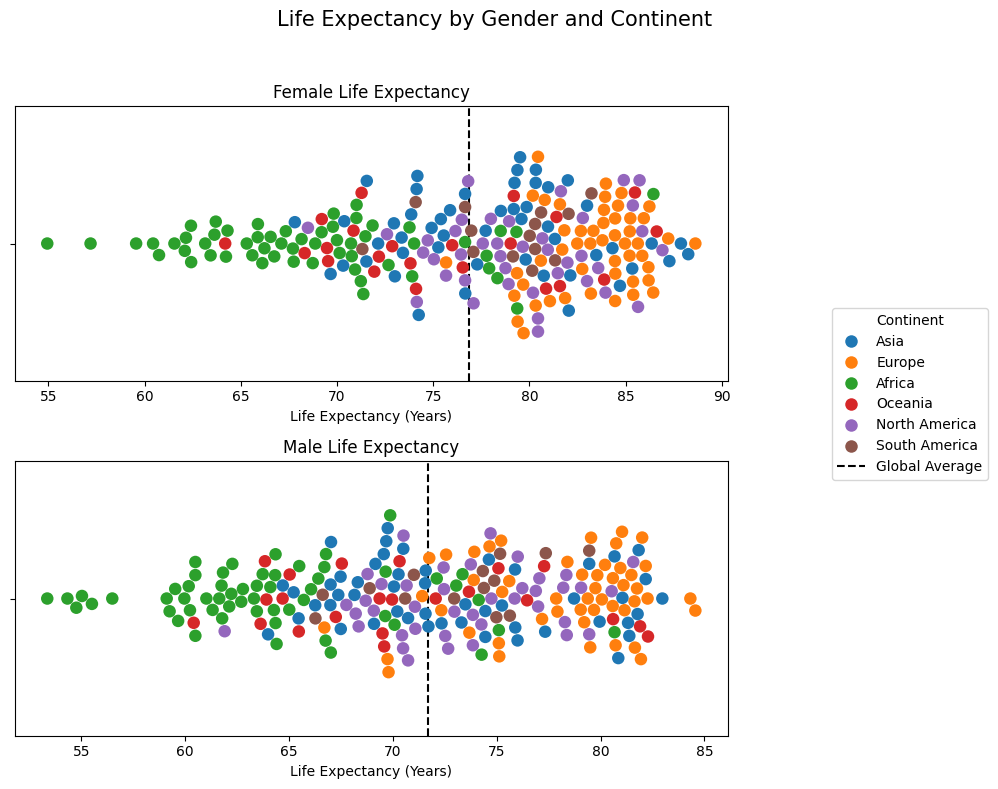

In [167]:
# Create a two-panel figure for comparing male and female life expectancy distributions
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# -----------------------------
# Female Life Expectancy Subplot
# -----------------------------
sns.swarmplot(
    data=life_expect_db_w_continents,
    x="Female_Life_Expectancy",
    hue="Continent",
    orient="h",
    size=9,
    native_scale=True,
    edgecolor=None,
    linewidth=0,
    ax=axes[0]
)

axes[0].set_title("Female Life Expectancy")
axes[0].set_xlabel("Life Expectancy (Years)")
axes[0].set_ylabel("")

# Remove subplot legend to enable a unified figure-level legend
axes[0].legend_.remove()

# -----------------------------
# Male Life Expectancy Subplot
# -----------------------------
sns.swarmplot(
    data=life_expect_db_w_continents,
    x="Male_Life_Expectancy",
    hue="Continent",
    orient="h",
    size=9,
    native_scale=True,
    edgecolor=None,
    linewidth=0,
    ax=axes[1]
)

axes[1].set_title("Male Life Expectancy")
axes[1].set_xlabel("Life Expectancy (Years)")
axes[1].set_ylabel("")

# Remove subplot legend to maintain a single consolidated legend
axes[1].legend_.remove()

# -----------------------------
# Global Mean Reference Lines
# -----------------------------
female_mean = life_expect_db_w_continents["Female_Life_Expectancy"].mean()
male_mean = life_expect_db_w_continents["Male_Life_Expectancy"].mean()

# Add reference lines representing global average life expectancy
axes[0].axvline(
    female_mean,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Global Average"
)

axes[1].axvline(
    male_mean,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Global Average"
)

# -----------------------------
# Shared Legend Construction
# -----------------------------

# Extract legend elements from one subplot to create a unified figure legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    title="Continent",
    loc="center right",
    bbox_to_anchor=(1, 0.5)
)

# -----------------------------
# Final Layout Adjustments
# -----------------------------
plt.suptitle("Life Expectancy by Gender and Continent", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.75, 0.95])
plt.show()